In [1]:
import os
os.environ['USE_PYGEOS'] = '0'
import sys

import numpy
import pandas
from datetime import datetime, timedelta
import pytz
import geopandas
import dask
import dask_geopandas
import shapely
from shapely import wkb, wkt
import requests
import json
import s3fs

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
dset_id = '553' # Land cover (Copernicus) v3
layer_id = '51353' # Classification
pixel_level = 20
numeric_or_categorical = 'categorical'
dimension_values = {}

print('numeric_or_categorical ', numeric_or_categorical)
print('dimension_values', dimension_values)

delta_pixel_overview = 8 # pixel_level - 14
print('delta_pixel_overview   ', delta_pixel_overview)
print('overview level         ', pixel_level - delta_pixel_overview)

# Valid range CONUS
valid_range = [-180, -90, 180, 90]
valid_range = shapely.box(*valid_range)
print('valid_range            ', valid_range.bounds)

numeric_or_categorical  categorical
dimension_values {}
delta_pixel_overview    8
overview level          12
valid_range             (-180.0, -90.0, 180.0, 90.0)


## Looking at the S3 folder

In [3]:
with open('data/service_credentials_geofm-sampling-strategies.json', 'r') as fp:
    service_credentials = json.load(fp)
    
service_credentials.keys()

dict_keys(['apikey', 'cos_hmac_keys', 'endpoints', 'iam_apikey_description', 'iam_apikey_name', 'iam_role_crn', 'iam_serviceid_crn', 'resource_instance_id'])

In [4]:
api_response = requests.get(service_credentials['endpoints'])
#api_response.json()
endpoint_url = api_response.json()['service-endpoints']['regional']['us-east']['public']['us-east']
endpoint_url = f'https://{endpoint_url}'
endpoint_url

'https://s3.us-east.cloud-object-storage.appdomain.cloud'

In [5]:
remote_fs = s3fs.S3FileSystem(
    key=service_credentials['cos_hmac_keys']['access_key_id'],
    secret=service_credentials['cos_hmac_keys']['secret_access_key'],
    client_kwargs={
         'endpoint_url': endpoint_url,
      }
)

In [6]:
bucket = 'geofm-sampling-strategies'
remote_root_folder = 's3://' + bucket
remote_root_folder

's3://geofm-sampling-strategies'

In [7]:
s3_dir = os.path.join(bucket, 'stats_' + layer_id).replace("\\","/")
remote_fs.ls(s3_dir)

['geofm-sampling-strategies/stats_51353/dset_id=553']

In [8]:
partition_dir = os.path.join(s3_dir, 'dset_id=' + dset_id).replace("\\","/")
partition_dir = os.path.join(partition_dir, 'layer_id=' + layer_id).replace("\\","/")
partition_dir = os.path.join(partition_dir, 'overview_level=' + str(pixel_level-delta_pixel_overview)).replace("\\","/")
remote_fs.ls(partition_dir)

['geofm-sampling-strategies/stats_51353/dset_id=553/layer_id=51353/overview_level=12/spatial_partition=0q0000222',
 'geofm-sampling-strategies/stats_51353/dset_id=553/layer_id=51353/overview_level=12/spatial_partition=0q0000223',
 'geofm-sampling-strategies/stats_51353/dset_id=553/layer_id=51353/overview_level=12/spatial_partition=0q0000232',
 'geofm-sampling-strategies/stats_51353/dset_id=553/layer_id=51353/overview_level=12/spatial_partition=0q0000233',
 'geofm-sampling-strategies/stats_51353/dset_id=553/layer_id=51353/overview_level=12/spatial_partition=0q0000322',
 'geofm-sampling-strategies/stats_51353/dset_id=553/layer_id=51353/overview_level=12/spatial_partition=0q0002000',
 'geofm-sampling-strategies/stats_51353/dset_id=553/layer_id=51353/overview_level=12/spatial_partition=0q0002001',
 'geofm-sampling-strategies/stats_51353/dset_id=553/layer_id=51353/overview_level=12/spatial_partition=0q0002002',
 'geofm-sampling-strategies/stats_51353/dset_id=553/layer_id=51353/overview_leve

## Accessing a single spatial overview partition without using mortoncurve or rasteroverview objects

In [9]:
idx = 300

remote_fp = remote_fs.ls(partition_dir)[idx]
print('remote_fp          ', remote_fp)
print()

spatial_partition = os.path.split(remote_fp)[-1].split('=')[1]
print('spatial_partition  ', spatial_partition)
print()

storage_url = f's3://{remote_fp}'
print('storage_url        ', storage_url)

remote_fp           geofm-sampling-strategies/stats_51353/dset_id=553/layer_id=51353/overview_level=12/spatial_partition=0q0023311

spatial_partition   0q0023311

storage_url         s3://geofm-sampling-strategies/stats_51353/dset_id=553/layer_id=51353/overview_level=12/spatial_partition=0q0023311


In [10]:
# Filter particular timestamp
dt1 = datetime(2019, 1, 1)

In [11]:
%%time
ddf = dask_geopandas.read_parquet(
    storage_url,
    storage_options={
        'key' : service_credentials['cos_hmac_keys']['access_key_id'],
        'secret' : service_credentials['cos_hmac_keys']['secret_access_key'],
        'client_kwargs' : {'endpoint_url': endpoint_url}
    },
    filters = [
        ('timestamp', '=', dt1),
    ],
)
ddf

CPU times: user 84 ms, sys: 5.61 ms, total: 89.6 ms
Wall time: 726 ms


,q_key,geometry,timestamp,count,unique,top,freq,first,count_200,count_80,count_90,count_126,count_20,count_30,count_60,count_116,count_121,count_40,count_50,count_111,count_0,dset_id,layer_id,overview_level,spatial_partition
npartitions=1,,,,,,,,,,,,,,,,,,,,,,,,,
,object,geometry,datetime64[ns],object,object,object,object,object,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,category[known],category[known],category[known],category[known]
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [12]:
gdf = ddf.compute().reset_index(drop=True)
gdf.tail(2)

,q_key,geometry,timestamp,count,unique,top,freq,first,count_200,count_80,...,count_116,count_121,count_40,count_50,count_111,count_0,dset_id,layer_id,overview_level,spatial_partition
1022,0q002331133332,"POLYGON ((-113.15328 31.50374, -113.15328 31.6...",2019-01-01,65536,4,20,63786,20,0,0,...,0,0,30,0,0,0,553,51353,12,0q0023311
1023,0q002331133333,"POLYGON ((-113.02221 31.50374, -113.02221 31.6...",2019-01-01,65536,4,20,46935,20,0,0,...,0,0,6005,0,0,0,553,51353,12,0q0023311


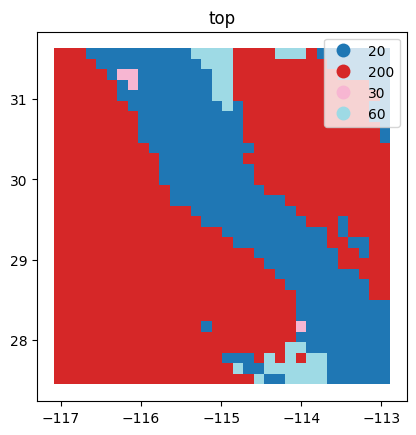

In [13]:
gdf.plot(gdf['top'], cmap='tab20', legend=True)
plt.title('top')
plt.show()

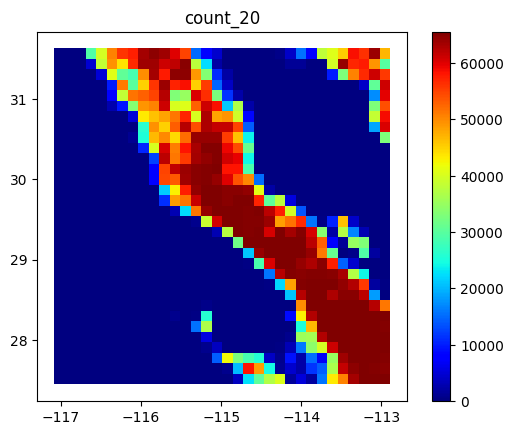

In [14]:
gdf.plot(gdf['count_20'], cmap='jet', legend=True)
plt.title('count_20')
plt.show()

## Copernicus classes

In [15]:
# Copernicus classes
# 0	#282828	Unknown. No or not enough satellite data available.
# 20	#ffbb22	Shrubs. Woody perennial plants with persistent and woody stems and without any defined main stem being less than 5 m tall. The shrub foliage can be either evergreen or deciduous.
# 30	#ffff4c	Herbaceous vegetation. Plants without persistent stem or shoots above ground and lacking definite firm structure. Tree and shrub cover is less than 10 %.
# 40	#f096ff	Cultivated and managed vegetation / agriculture. Lands covered with temporary crops followed by harvest and a bare soil period (e.g., single and multiple cropping systems). Note that perennial woody crops will be classified as the appropriate forest or shrub land cover type.
# 50	#fa0000	Urban / built up. Land covered by buildings and other man-made structures.
# 60	#b4b4b4	Bare / sparse vegetation. Lands with exposed soil, sand, or rocks and never has more than 10 % vegetated cover during any time of the year.
# 70	#f0f0f0	Snow and ice. Lands under snow or ice cover throughout the year.
# 80	#0032c8	Permanent water bodies. Lakes, reservoirs, and rivers. Can be either fresh or salt-water bodies.
# 90	#0096a0	Herbaceous wetland. Lands with a permanent mixture of water and herbaceous or woody vegetation. The vegetation can be present in either salt, brackish, or fresh water.
# 100	#fae6a0	Moss and lichen.
# 111	#58481f	Closed forest, evergreen needle leaf. Tree canopy >70 %, almost all needle leaf trees remain green all year. Canopy is never without green foliage.
# 112	#009900	Closed forest, evergreen broad leaf. Tree canopy >70 %, almost all broadleaf trees remain green year round. Canopy is never without green foliage.
# 113	#70663e	Closed forest, deciduous needle leaf. Tree canopy >70 %, consists of seasonal needle leaf tree communities with an annual cycle of leaf-on and leaf-off periods.
# 114	#00cc00	Closed forest, deciduous broad leaf. Tree canopy >70 %, consists of seasonal broadleaf tree communities with an annual cycle of leaf-on and leaf-off periods.
# 115	#4e751f	Closed forest, mixed.
# 116	#007800	Closed forest, not matching any of the other definitions.
# 121	#666000	Open forest, evergreen needle leaf. Top layer- trees 15-70 % and second layer- mixed of shrubs and grassland, almost all needle leaf trees remain green all year. Canopy is never without green foliage.
# 122	#8db400	Open forest, evergreen broad leaf. Top layer- trees 15-70 % and second layer- mixed of shrubs and grassland, almost all broadleaf trees remain green year round. Canopy is never without green foliage.
# 123	#8d7400	Open forest, deciduous needle leaf. Top layer- trees 15-70 % and second layer- mixed of shrubs and grassland, consists of seasonal needle leaf tree communities with an annual cycle of leaf-on and leaf-off periods.
# 124	#a0dc00	Open forest, deciduous broad leaf. Top layer- trees 15-70 % and second layer- mixed of shrubs and grassland, consists of seasonal broadleaf tree communities with an annual cycle of leaf-on and leaf-off periods.
# 125	#929900	Open forest, mixed.
# 126	#648c00	Open forest, not matching any of the other definitions.
# 200	#000080	Oceans, seas. Can be either fresh or salt-water bodies.

## Query entire parquet store

In [16]:
#s3_dir = 'geofm-sampling-strategies/stats_51353'
print('s3_dir       ', s3_dir)
print()

# Filter particular timestamp
dt1 = datetime(2019, 1, 1)
print('dt1          ', dt1)
print()

storage_url = f's3://{s3_dir}'
print('storage_url  ', storage_url)

s3_dir        geofm-sampling-strategies/stats_51353

dt1           2019-01-01 00:00:00

storage_url   s3://geofm-sampling-strategies/stats_51353


In [17]:
%%time
ddf = dask_geopandas.read_parquet(
    storage_url,
    storage_options={
        'key' : service_credentials['cos_hmac_keys']['access_key_id'],
        'secret' : service_credentials['cos_hmac_keys']['secret_access_key'],
        'client_kwargs' : {'endpoint_url': endpoint_url}
    },
    filters = [
        ('timestamp', '=', dt1),
    ],   
)
ddf

CPU times: user 29.9 s, sys: 2.39 s, total: 32.3 s
Wall time: 1min 38s


,q_key,geometry,timestamp,count,unique,top,freq,first,count_200,dset_id,layer_id,overview_level,spatial_partition
npartitions=2305,,,,,,,,,,,,,
,object,geometry,datetime64[ns],object,object,object,object,object,int64,category[known],category[known],category[known],category[known]
,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...


In [18]:
%%time
gdf = ddf.compute().reset_index(drop=True)
gdf.tail(2)

CPU times: user 1min 53s, sys: 15.7 s, total: 2min 9s
Wall time: 1min 45s


,q_key,geometry,timestamp,count,unique,top,freq,first,count_200,dset_id,layer_id,overview_level,spatial_partition
2192867,0q121210131001,"POLYGON ((179.79264 79.86931, 179.79264 80.000...",2019-01-01,65280,1,200,65280,200,65280.0,553,51353,12,0q1212101
2192868,0q121210131010,"POLYGON ((179.92371 79.86931, 179.92371 80.000...",2019-01-01,37995,1,200,37995,200,37995.0,553,51353,12,0q1212101


In [19]:
# ax = gdf.plot(gdf['top'], cmap='tab20', figsize=(20,20))
# ax.set_aspect(1.5)
# plt.show()

gdf_land 880397


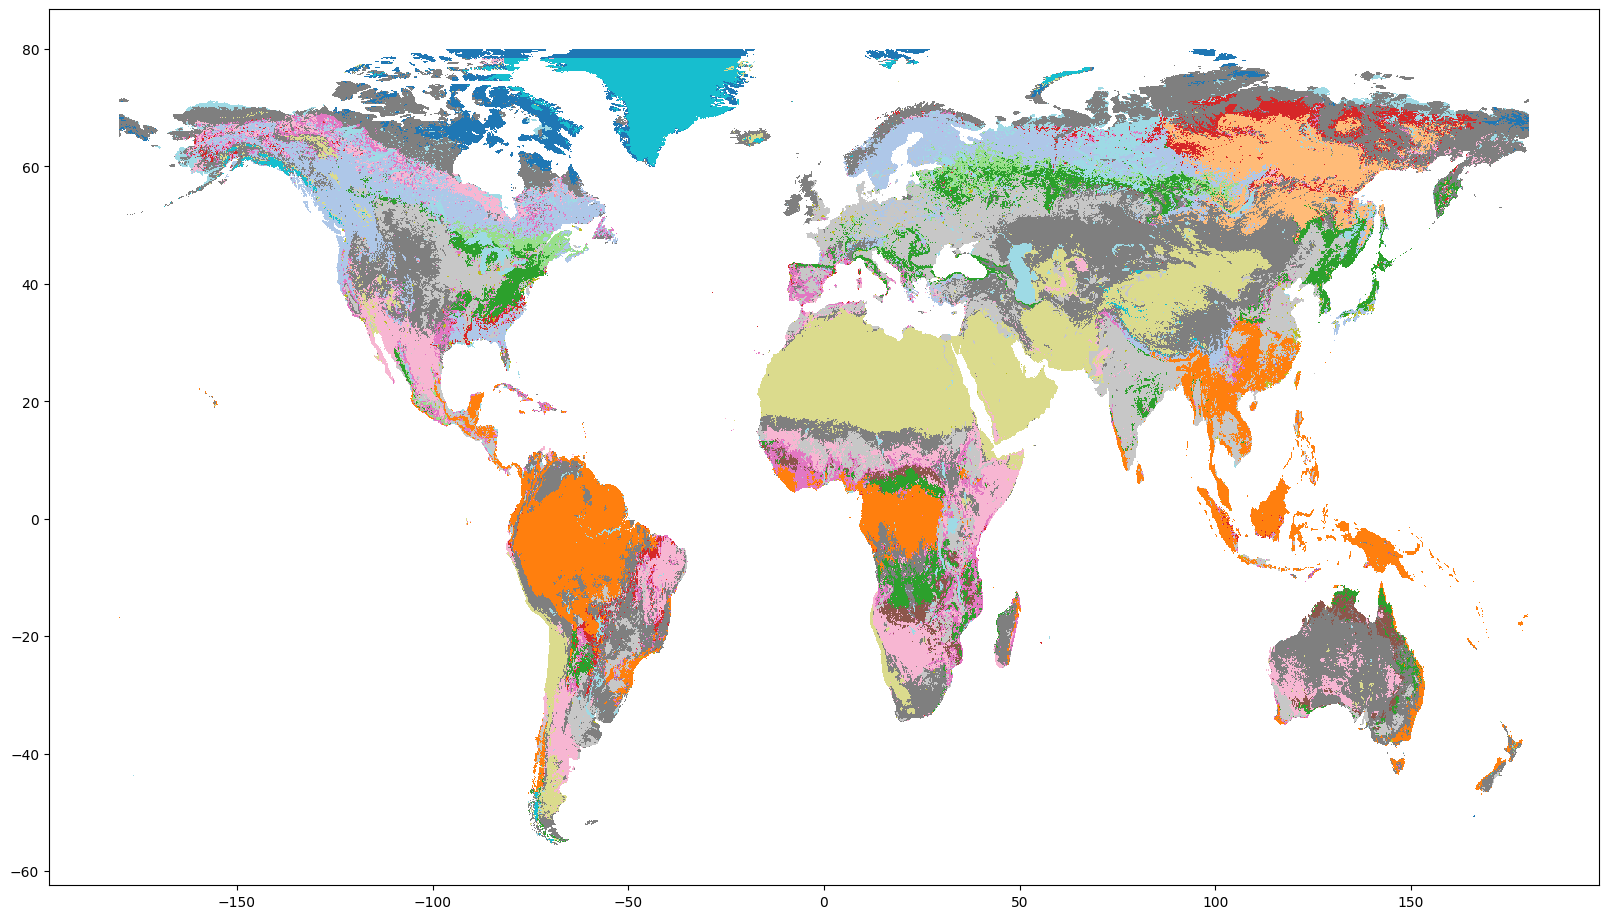

,q_key,geometry,timestamp,count,unique,top,freq,first,count_200,dset_id,layer_id,overview_level,spatial_partition
880395,0q121032113230,"POLYGON ((179.92371 71.21856, 179.92371 71.349...",2019-01-01,38132,2,30,36530,30,0.0,553,51353,12,0q1210321
880396,0q121032113232,"POLYGON ((179.92371 71.34963, 179.92371 71.480...",2019-01-01,38144,3,30,35934,30,0.0,553,51353,12,0q1210321


In [20]:
gdf_land = gdf[gdf['top']!='200'].reset_index(drop=True)
print('gdf_land', len(gdf_land))
ax = gdf_land.plot(gdf_land['top'], cmap='tab20', figsize=(20,20))
ax.set_aspect(1.5)
plt.show()
gdf_land.tail(2)

## Combining some forest classes 

In [21]:
rename_map = {
    0: "unknown", # -> skip
    20: "shrubs",
    30: "herbaceous_vegetation",
    40: "managed_vegetation",
    50: "urban",
    60: "bare_vegetation",
    70: "ice",
    80: "permanent_water",
    90: "wetland",
    100: "moss",
    111: "closed_forest",
    112: "closed_forest",
    113: "closed_forest",
    114: "closed_forest",
    115: "closed_forest",
    116: "closed_forest",
    121: "open_forest",
    122: "open_forest",
    123: "open_forest",
    124: "open_forest",
    125: "open_forest",
    126: "open_forest",
}
gdf_land_wgs84 = gdf_land[['top', 'geometry']]
gdf_land_wgs84['new_labels'] = gdf_land_wgs84['top'].astype(int).replace(rename_map)
gdf_land_wgs84 = gdf_land_wgs84[gdf_land_wgs84['new_labels']!='unknown'].reset_index(drop=True)
gdf_land_wgs84.tail()

/data/mfreitag/software/shapely20dev/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,top,geometry,new_labels
872528,30,"POLYGON ((179.79264 71.21856, 179.79264 71.349...",herbaceous_vegetation
872529,30,"POLYGON ((179.66157 71.34963, 179.66157 71.480...",herbaceous_vegetation
872530,30,"POLYGON ((179.79264 71.34963, 179.79264 71.480...",herbaceous_vegetation
872531,30,"POLYGON ((179.92371 71.21856, 179.92371 71.349...",herbaceous_vegetation
872532,30,"POLYGON ((179.92371 71.34963, 179.92371 71.480...",herbaceous_vegetation


In [22]:
gdf_land_wgs84.groupby('new_labels').count()

,top,geometry
new_labels,,
bare_vegetation,111398,111398
closed_forest,259512,259512
herbaceous_vegetation,216434,216434
ice,28832,28832
managed_vegetation,102904,102904
moss,18561,18561
open_forest,42495,42495
permanent_water,14267,14267
shrubs,56904,56904


In [23]:
# Remember the center Longitude and Latitude for every pixel
gdf_land_wgs84['Centroid'] = gdf_land_wgs84['geometry'].centroid
gdf_land_wgs84['Longitude'] = gdf_land_wgs84['geometry'].centroid.x
gdf_land_wgs84['Latitude'] = gdf_land_wgs84['geometry'].centroid.y
gdf_land_wgs84

,top,geometry,new_labels,Centroid,Longitude,Latitude
0,90,"POLYGON ((-176.59213 -44.12480, -176.59213 -43...",wetland,POINT (-176.52659 -44.05926),-176.526592,-44.059264
1,80,"POLYGON ((-176.59213 -43.86266, -176.59213 -43...",permanent_water,POINT (-176.52659 -43.79712),-176.526592,-43.797120
2,80,"POLYGON ((-176.46106 -43.86266, -176.46106 -43...",permanent_water,POINT (-176.39552 -43.79712),-176.395520,-43.797120
3,60,"POLYGON ((-71.99667 -54.61056, -71.99667 -54.4...",bare_vegetation,POINT (-71.93114 -54.54502),-71.931136,-54.545024
4,60,"POLYGON ((-71.86560 -54.61056, -71.86560 -54.4...",bare_vegetation,POINT (-71.80006 -54.54502),-71.800064,-54.545024
...,...,...,...,...,...,...
872528,30,"POLYGON ((179.79264 71.21856, 179.79264 71.349...",herbaceous_vegetation,POINT (179.85818 71.28410),179.858176,71.284096
872529,30,"POLYGON ((179.66157 71.34963, 179.66157 71.480...",herbaceous_vegetation,POINT (179.72710 71.41517),179.727104,71.415168
872530,30,"POLYGON ((179.79264 71.34963, 179.79264 71.480...",herbaceous_vegetation,POINT (179.85818 71.41517),179.858176,71.415168
872531,30,"POLYGON ((179.92371 71.21856, 179.92371 71.349...",herbaceous_vegetation,POINT (179.96186 71.28410),179.961856,71.284096


## Create some area weights and do a weighted sampling

In [24]:
gdf_land_wgs84['area_weights'] = gdf_land_wgs84['Latitude'].apply(
    lambda x: numpy.cos(numpy.deg2rad(x))
)
gdf_land_wgs84.tail(2)

,top,geometry,new_labels,Centroid,Longitude,Latitude,area_weights
872531,30,"POLYGON ((179.92371 71.21856, 179.92371 71.349...",herbaceous_vegetation,POINT (179.96186 71.28410),179.961856,71.284096,0.320876
872532,30,"POLYGON ((179.92371 71.34963, 179.92371 71.480...",herbaceous_vegetation,POINT (179.96186 71.41517),179.961856,71.415168,0.318708


In [25]:
new_labels = sorted(gdf_land_wgs84['new_labels'].unique())
picked_labels = [l for l in new_labels if l not in ['ice', 'moss', 'permanent_water']]

In [26]:
# Find out fraction of acreage covered by each category we are interested in
gdf_land_picked_labels = gdf_land_wgs84[gdf_land_wgs84['new_labels'].isin(picked_labels)]
df_fraction = gdf_land_picked_labels.groupby('new_labels').sum()['area_weights'] / gdf_land_picked_labels['area_weights'].sum()
df_fraction = df_fraction.reset_index().rename(columns={'area_weights': 'fraction'})
df_fraction

/tmp/ipykernel_993719/3466482051.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_fraction = gdf_land_picked_labels.groupby('new_labels').sum()['area_weights'] / gdf_land_picked_labels['area_weights'].sum()


,new_labels,fraction
0,bare_vegetation,0.159208
1,closed_forest,0.307038
2,herbaceous_vegetation,0.240071
3,managed_vegetation,0.134967
4,open_forest,0.059700
5,shrubs,0.079795
6,urban,0.003683
7,wetland,0.015538


In [27]:
total_number_of_items_to_pick = 1000
draws = []
for new_label in picked_labels:
    # Unbiased sampling by area
    number_of_items_to_pick = round(total_number_of_items_to_pick * float(
        df_fraction.loc[df_fraction['new_labels']==new_label, 'fraction']
    ))
    print('unbiased:', new_label, number_of_items_to_pick)
    
    # Here we can further weigh individual labels by adjusting number_of_items_to_pick
    if new_label == 'urban':
        number_of_items_to_pick = number_of_items_to_pick * 10
    if new_label == 'bare_vegetation':
        number_of_items_to_pick = round(number_of_items_to_pick / 2)
    print('adjusted:', new_label, number_of_items_to_pick)
    
    gdf = gdf_land_wgs84[gdf_land_wgs84['new_labels']==new_label].reset_index(drop=True)
    # p is a probability distribution
    draw = numpy.random.choice(
        gdf['geometry'],
        size=number_of_items_to_pick, 
        replace=False,
        p=gdf['area_weights']/gdf['area_weights'].sum(),
    )
    df = pandas.DataFrame(draw).rename(columns={0: 'geometry'})
    df['new_labels'] = new_label
    draws.append(df)
df_draws = pandas.concat(draws).reset_index(drop=True)
gdf_draws = geopandas.GeoDataFrame(df_draws, geometry='geometry').set_crs(4326)
gdf_draws

unbiased: bare_vegetation 159
adjusted: bare_vegetation 80
unbiased: closed_forest 307
adjusted: closed_forest 307
unbiased: herbaceous_vegetation 240
adjusted: herbaceous_vegetation 240
unbiased: managed_vegetation 135
adjusted: managed_vegetation 135
unbiased: open_forest 60
adjusted: open_forest 60
unbiased: shrubs 80
adjusted: shrubs 80
unbiased: urban 4
adjusted: urban 40
unbiased: wetland 16
adjusted: wetland 16


,geometry,new_labels
0,"POLYGON ((80.17792 33.99411, 80.17792 34.12518...",bare_vegetation
1,"POLYGON ((6.90867 32.02803, 6.90867 32.15910, ...",bare_vegetation
2,"POLYGON ((-4.36352 24.81907, -4.36352 24.95014...",bare_vegetation
3,"POLYGON ((67.85715 31.11053, 67.85715 31.24160...",bare_vegetation
4,"POLYGON ((-8.16461 22.06656, -8.16461 22.19763...",bare_vegetation
...,...,...
953,"POLYGON ((30.37056 51.16454, 30.37056 51.29562...",wetland
954,"POLYGON ((53.17709 68.59712, 53.17709 68.72819...",wetland
955,"POLYGON ((154.10253 59.81530, 154.10253 59.946...",wetland
956,"POLYGON ((79.65363 59.68422, 79.65363 59.81530...",wetland


/tmp/ipykernel_993719/680880509.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_plot['geometry'] = gdf_plot.buffer(1)


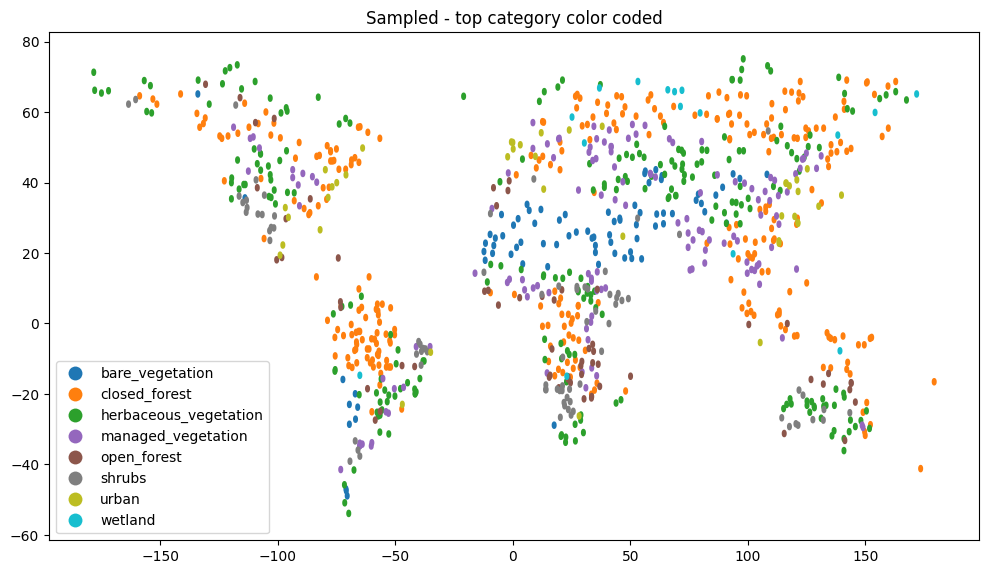

In [28]:
gdf_plot = gdf_draws.copy()
gdf_plot['geometry'] = gdf_plot.buffer(1)
fig, ax = plt.subplots(figsize=(12,12))
gdf_plot.plot(column="new_labels", legend=True, legend_kwds={'loc': 'lower left'}, ax=ax)
ax.set_aspect(1.5)
plt.title('Sampled - top category color coded')
plt.show()

## Reproject to equal area grid

In [29]:
# Explicitely set the crs so that we can reproject
gdf_land_wgs84 = gdf_land_wgs84.set_crs('4326')

# Reproject
#gdf_land_sinusoidal = gdf_land_wgs84.to_crs('54008') # Sinusoidal
#gdf_land_sinusoidal = gdf_land_wgs84.to_crs('1078') # Equal Earth
#gdf_land_sinusoidal = gdf_land_wgs84.to_crs('6974') # MODIS Sinusoidal
gdf_land_aea = gdf_land_wgs84.to_crs('9822') # Albers Equal Area
gdf_land_aea.tail(2)

,top,geometry,new_labels,Centroid,Longitude,Latitude,area_weights
872531,30,"POLYGON ((4920774.463 10034098.552, 4905456.54...",herbaceous_vegetation,POINT (179.96186 71.28410),179.961856,71.284096,0.320876
872532,30,"POLYGON ((4905456.547 10025820.158, 4890107.90...",herbaceous_vegetation,POINT (179.96186 71.41517),179.961856,71.415168,0.318708


In [30]:
# Remove a few pixels that make problems in this projection
gdf_land_aea = gdf_land_aea[~gdf_land_aea.intersects(shapely.box(-1e5, 1.02e7, 1e5, 2e7))]

<AxesSubplot: >

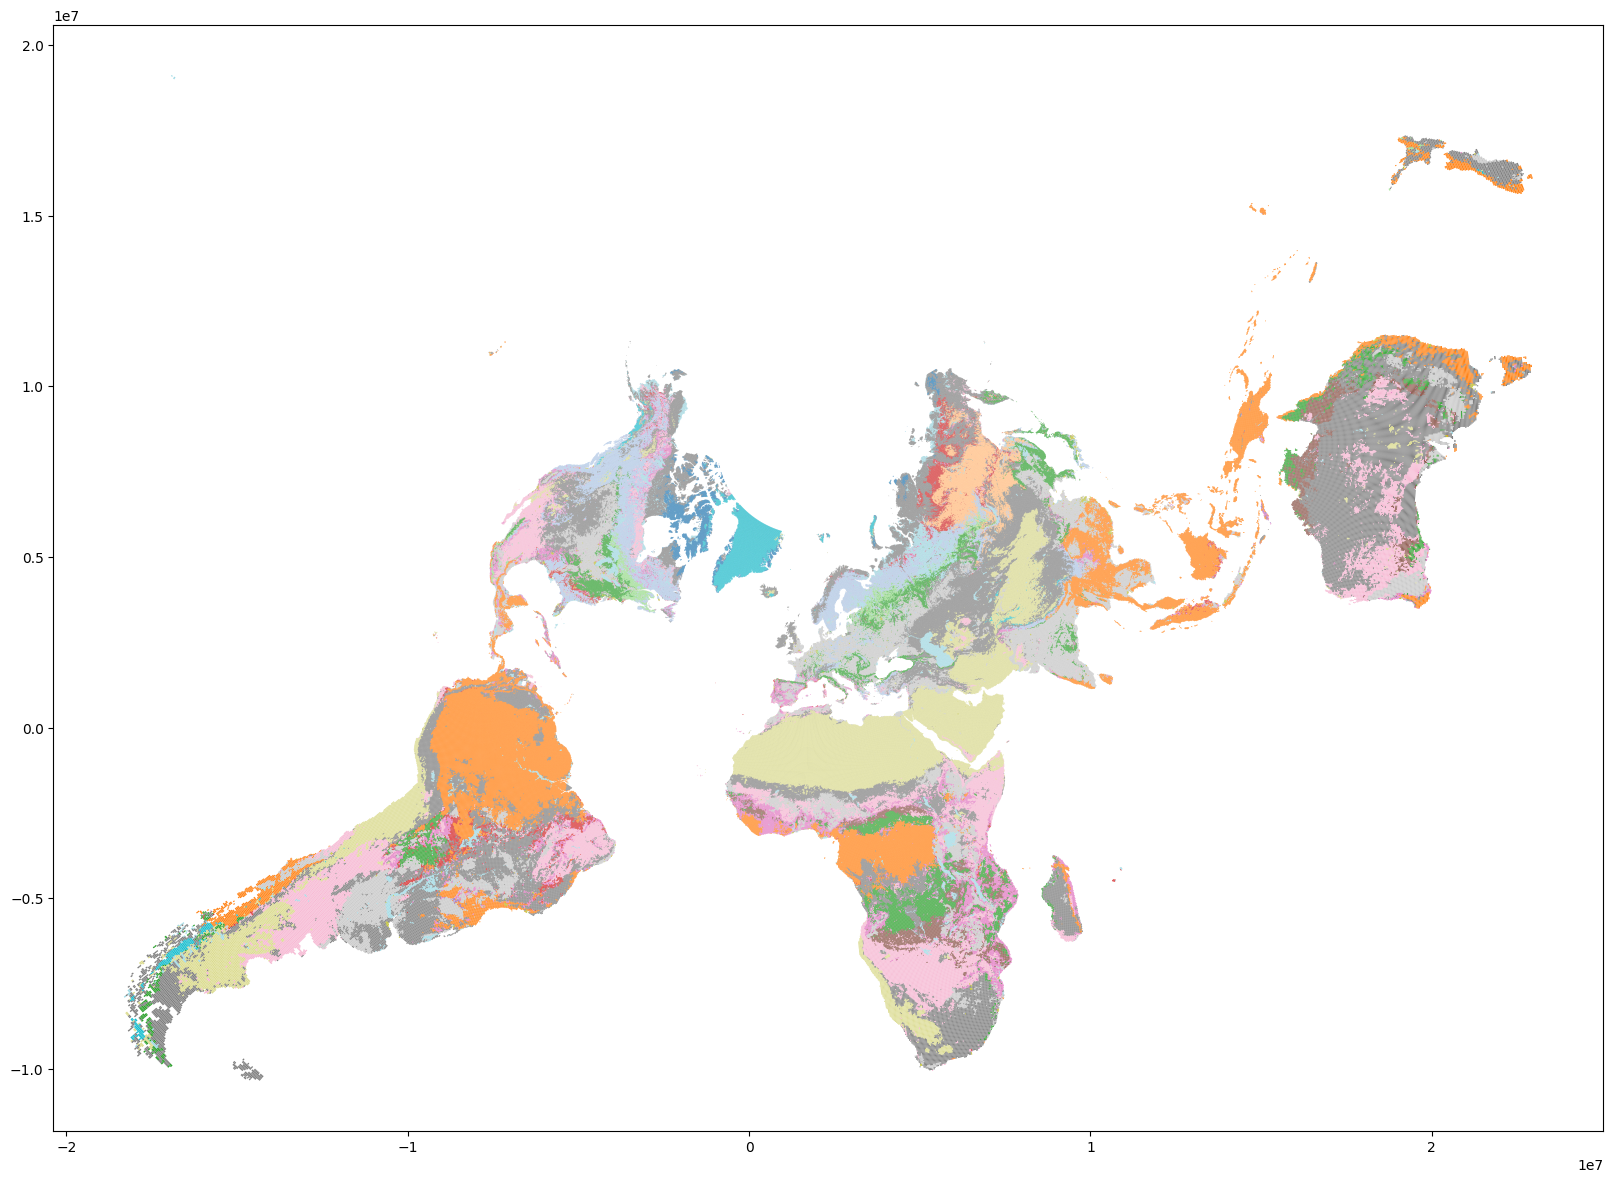

In [31]:
gdf_land_aea.plot(gdf_land_aea['top'], cmap='tab20', figsize=(20,20))

In [32]:
gdf_land_aea['area'] = gdf_land_aea.area
gdf_land_aea

,top,geometry,new_labels,Centroid,Longitude,Latitude,area_weights,area
0,90,"POLYGON ((-16921734.819 19120297.801, -1688224...",wetland,POINT (-176.52659 -44.05926),-176.526592,-44.059264,0.718621,1.504525e+09
1,80,"POLYGON ((-16842930.644 19074480.404, -1680378...",permanent_water,POINT (-176.52659 -43.79712),-176.526592,-43.797120,0.721795,1.485226e+09
2,80,"POLYGON ((-16859412.195 19046082.767, -1682023...",permanent_water,POINT (-176.39552 -43.79712),-176.395520,-43.797120,0.721795,1.485226e+09
3,60,"POLYGON ((-18277500.166 -8360598.047, -1822496...",bare_vegetation,POINT (-71.93114 -54.54502),-71.931136,-54.545024,0.580063,2.719325e+09
4,60,"POLYGON ((-18251983.177 -8391159.539, -1819951...",bare_vegetation,POINT (-71.80006 -54.54502),-71.800064,-54.545024,0.580063,2.719325e+09
...,...,...,...,...,...,...,...,...
872528,30,"POLYGON ((4923435.199 10029166.240, 4908104.62...",herbaceous_vegetation,POINT (179.85818 71.28410),179.858176,71.284096,0.320876,9.734732e+07
872529,30,"POLYGON ((4910745.193 10015998.402, 4895371.23...",herbaceous_vegetation,POINT (179.72710 71.41517),179.727104,71.415168,0.318708,9.707709e+07
872530,30,"POLYGON ((4908104.629 10020911.304, 4892743.30...",herbaceous_vegetation,POINT (179.85818 71.41517),179.858176,71.415168,0.318708,9.707709e+07
872531,30,"POLYGON ((4920774.463 10034098.552, 4905456.54...",herbaceous_vegetation,POINT (179.96186 71.28410),179.961856,71.284096,0.320876,5.665920e+07


## Debugging pyproj incompatibilities

In [33]:
import pyproj
pyproj.show_versions()

pyproj info:
    pyproj: 3.4.0
      PROJ: 9.1.0
  data dir: /data/mfreitag/software/shapely20dev/lib/python3.9/site-packages/pyproj/proj_dir/share/proj
user_data_dir: /home/mfreitag/.local/share/proj
PROJ DATA (recommended version): 1.11
PROJ Database: 1.2
EPSG Database: v10.074 [2022-08-01]
ESRI Database: ArcGIS Pro 3.0 [2022-07-09]
IGNF Database: 3.1.0 [2019-05-24]

System:
    python: 3.9.16 (main, Dec  7 2022, 01:11:58)  [GCC 7.5.0]
executable: /data/mfreitag/software/shapely20dev/bin/python3.9
   machine: Linux-5.4.0-137-generic-x86_64-with-glibc2.31

Python deps:
   certifi: 2022.9.24
    Cython: None
setuptools: 58.1.0
       pip: 23.1.1


In [34]:
geopandas.show_versions()


SYSTEM INFO
-----------
python     : 3.9.16 (main, Dec  7 2022, 01:11:58)  [GCC 7.5.0]
executable : /data/mfreitag/software/shapely20dev/bin/python3.9
machine    : Linux-5.4.0-137-generic-x86_64-with-glibc2.31

GEOS, GDAL, PROJ INFO
---------------------
GEOS       : 3.10.3
GEOS lib   : None
GDAL       : 3.4.3
GDAL data dir: /data/mfreitag/software/shapely20dev/lib/python3.9/site-packages/fiona/gdal_data
PROJ       : 9.1.0
PROJ data dir: /data/mfreitag/software/shapely20dev/lib/python3.9/site-packages/pyproj/proj_dir/share/proj

PYTHON DEPENDENCIES
-------------------
geopandas  : 0.12.1
numpy      : 1.23.4
pandas     : 1.5.1
pyproj     : 3.4.0
shapely    : 2.0a1
fiona      : 1.8.22
geoalchemy2: None
geopy      : 2.2.0
matplotlib : 3.6.2
mapclassify: None
pygeos     : 0.13
pyogrio    : None
psycopg2   : 2.9.5 (dt dec pq3 ext lo64)
pyarrow    : 12.0.0
rtree      : 1.0.1


In [35]:
pyproj.datadir.get_data_dir()

'/data/mfreitag/software/shapely20dev/lib/python3.9/site-packages/pyproj/proj_dir/share/proj'

In [36]:
#pyproj.datadir.set_data_dir('/data/mfreitag/software/shapely20dev/lib/python3.9/site-packages/pyproj/proj_dir/share/proj')
#pyproj.datadir.set_data_dir('/data/mfreitag/software/python39/lib/python3.9/site-packages/pyproj/proj_dir/share/proj')

In [37]:
print(pyproj.pj_list)

{'adams_hemi': 'Adams Hemisphere in a Square', 'adams_ws1': 'Adams World in a Square I', 'adams_ws2': 'Adams World in a Square II', 'aea': 'Albers Equal Area', 'aeqd': 'Azimuthal Equidistant', 'affine': 'Affine transformation', 'airy': 'Airy', 'aitoff': 'Aitoff', 'alsk': 'Modified Stereographic of Alaska', 'apian': 'Apian Globular I', 'august': 'August Epicycloidal', 'axisswap': 'Axis ordering', 'bacon': 'Bacon Globular', 'bertin1953': 'Bertin 1953', 'bipc': 'Bipolar conic of western hemisphere', 'boggs': 'Boggs Eumorphic', 'bonne': 'Bonne (Werner lat_1=90)', 'calcofi': 'Cal Coop Ocean Fish Invest Lines/Stations', 'cart': 'Geodetic/cartesian conversions', 'cass': 'Cassini', 'cc': 'Central Cylindrical', 'ccon': 'Central Conic', 'cea': 'Equal Area Cylindrical', 'chamb': 'Chamberlin Trimetric', 'collg': 'Collignon', 'col_urban': 'Colombia Urban', 'comill': 'Compact Miller', 'crast': 'Craster Parabolic (Putnins P4)', 'defmodel': 'Deformation model', 'deformation': 'Kinematic grid shift', '

## Special case histogram columns

Because histogram column names may be different for every parquet file, we need to query them separately if we are interested in those

In [38]:
# Choose a histogram column for later on or to limit the returned columns
hist_col = 'count_50' # Urban 
print('hist_col         ', hist_col)

# Filter particular timestamp
dt1 = datetime(2019, 1, 1)
print('dt1              ', dt1)

# Figure out all the remote parquet filepaths
remote_filepaths = []
for p in remote_fs.ls(partition_dir):
    remote_filepaths.extend(remote_fs.ls(p))
print('remote_filepaths ', len(remote_filepaths))

hist_col          count_50
dt1               2019-01-01 00:00:00
remote_filepaths  2305


In [39]:
%%time
gdf_hist = []
for remote_fp in remote_filepaths:
    storage_url = f's3://{remote_fp}'
    #print('storage_url        ', storage_url)
    try:
        ddf1 = dask_geopandas.read_parquet(
            storage_url,
            storage_options={
                'key' : service_credentials['cos_hmac_keys']['access_key_id'],
                'secret' : service_credentials['cos_hmac_keys']['secret_access_key'],
                'client_kwargs' : {'endpoint_url': endpoint_url}
            },
            filters = [
                ('timestamp', '=', dt1),
            ],   
            #columns=['q_key', 'geometry', 'timestamp', 'count', hist_col]
        )

    except:
        pass
    else:
        gdf_hist.append(ddf1.compute())
gdf_hist = pandas.concat(gdf_hist).reset_index(drop=True)
gdf_hist.tail(2)

CPU times: user 3min 54s, sys: 55.5 s, total: 4min 49s
Wall time: 9min 48s


,q_key,geometry,timestamp,count,unique,top,freq,first,count_200,dset_id,...,count_124,count_70,count_50,count_115,count_121,count_111,count_125,count_100,count_113,count_123
2192867,0q121210131001,"POLYGON ((179.79264 79.86931, 179.79264 80.000...",2019-01-01,65280,1,200,65280,200,65280.0,553,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2192868,0q121210131010,"POLYGON ((179.92371 79.86931, 179.92371 80.000...",2019-01-01,37995,1,200,37995,200,37995.0,553,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


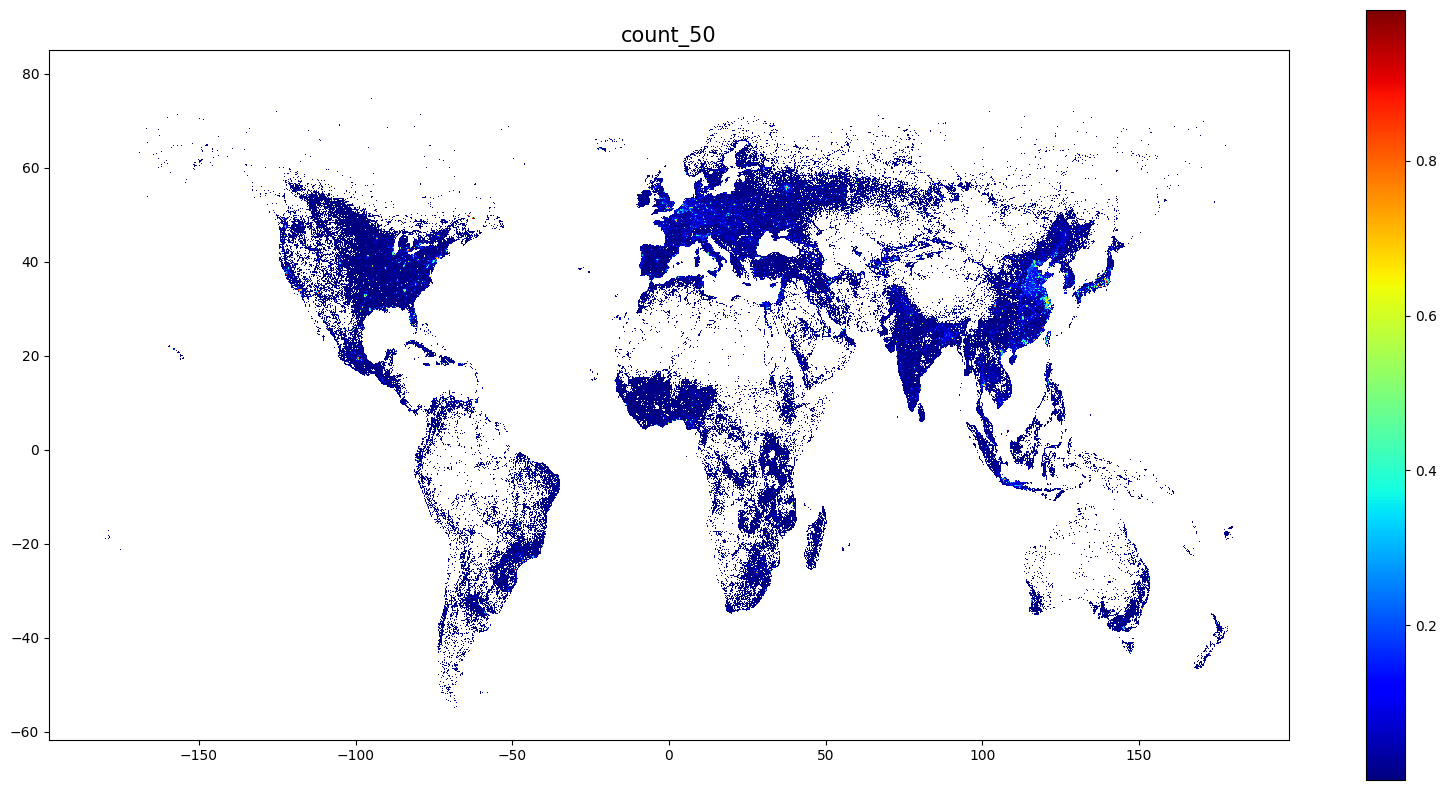

In [40]:
gdf_plot = gdf_hist[gdf_hist[hist_col]>0]

ax = gdf_plot.plot(
    gdf_plot[hist_col]/gdf_plot['count'],
    cmap='jet',
    figsize=(20,10),
    legend=True,
)
ax.set_aspect(1.5)
# plt.xlim(-80, -40)
# plt.ylim(-50, -10)
plt.title(hist_col, size=15)
plt.show()

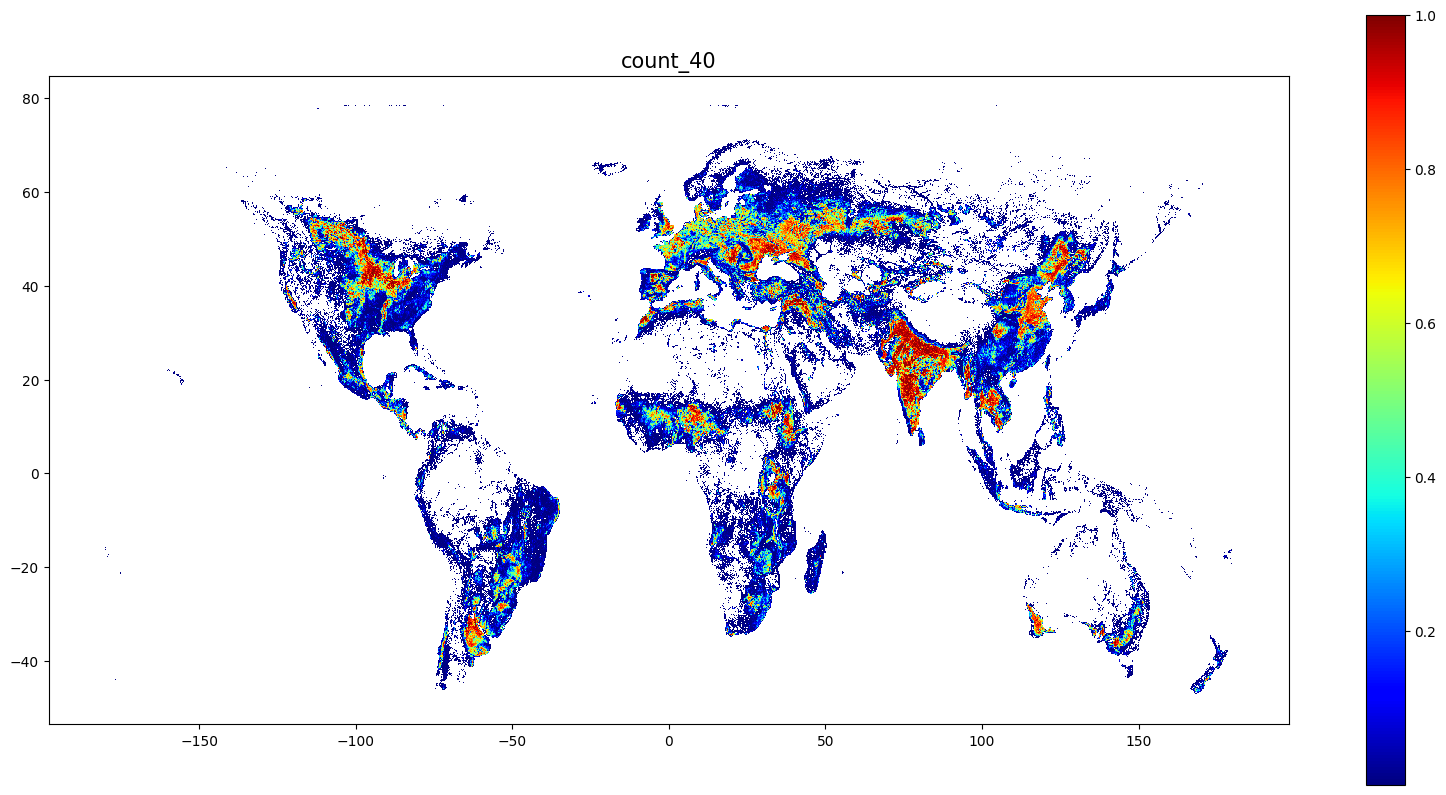

In [41]:
hist_col = 'count_40' # Agriculture
gdf_plot = gdf_hist[gdf_hist[hist_col]>0]

ax = gdf_plot.plot(
    gdf_plot[hist_col]/gdf_plot['count'],
    cmap='jet',
    figsize=(20,10),
    legend=True,
)
ax.set_aspect(1.5)
# plt.xlim(-80, -40)
# plt.ylim(-50, -10)
plt.title(hist_col, size=15)
plt.show()

In [42]:
# Combining multiple forest categories
hist_cols = [
    'count_111', # Closed forest, evergreen needle leaf.
    'count_112', # Closed forest, evergreen broad leaf.
    'count_113', # Closed forest, deciduous needle leaf.
    'count_114', # Closed forest, deciduous broad leaf.
    'count_115', # Closed forest, mixed.
    'count_116', # Closed forest, not matching any of the other definitions.
]
gdf_hist['count_forest'] = gdf_hist[hist_cols].sum(axis=1)

# Combining multiple savanna categories
hist_cols = [
    'count_121', # Open forest, evergreen needle leaf.
    'count_122', # Open forest, evergreen broad leaf.
    'count_123', # Open forest, deciduous needle leaf.
    'count_124', # Open forest, deciduous broad leaf.
    'count_125', # Open forest, mixed.
    'count_126', # Open forest, not matching any of the other definitions.
]
gdf_hist['count_savanna'] = gdf_hist[hist_cols].sum(axis=1)

gdf_hist.tail(2)

,q_key,geometry,timestamp,count,unique,top,freq,first,count_200,dset_id,...,count_50,count_115,count_121,count_111,count_125,count_100,count_113,count_123,count_forest,count_savanna
2192867,0q121210131001,"POLYGON ((179.79264 79.86931, 179.79264 80.000...",2019-01-01,65280,1,200,65280,200,65280.0,553,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2192868,0q121210131010,"POLYGON ((179.92371 79.86931, 179.92371 80.000...",2019-01-01,37995,1,200,37995,200,37995.0,553,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0


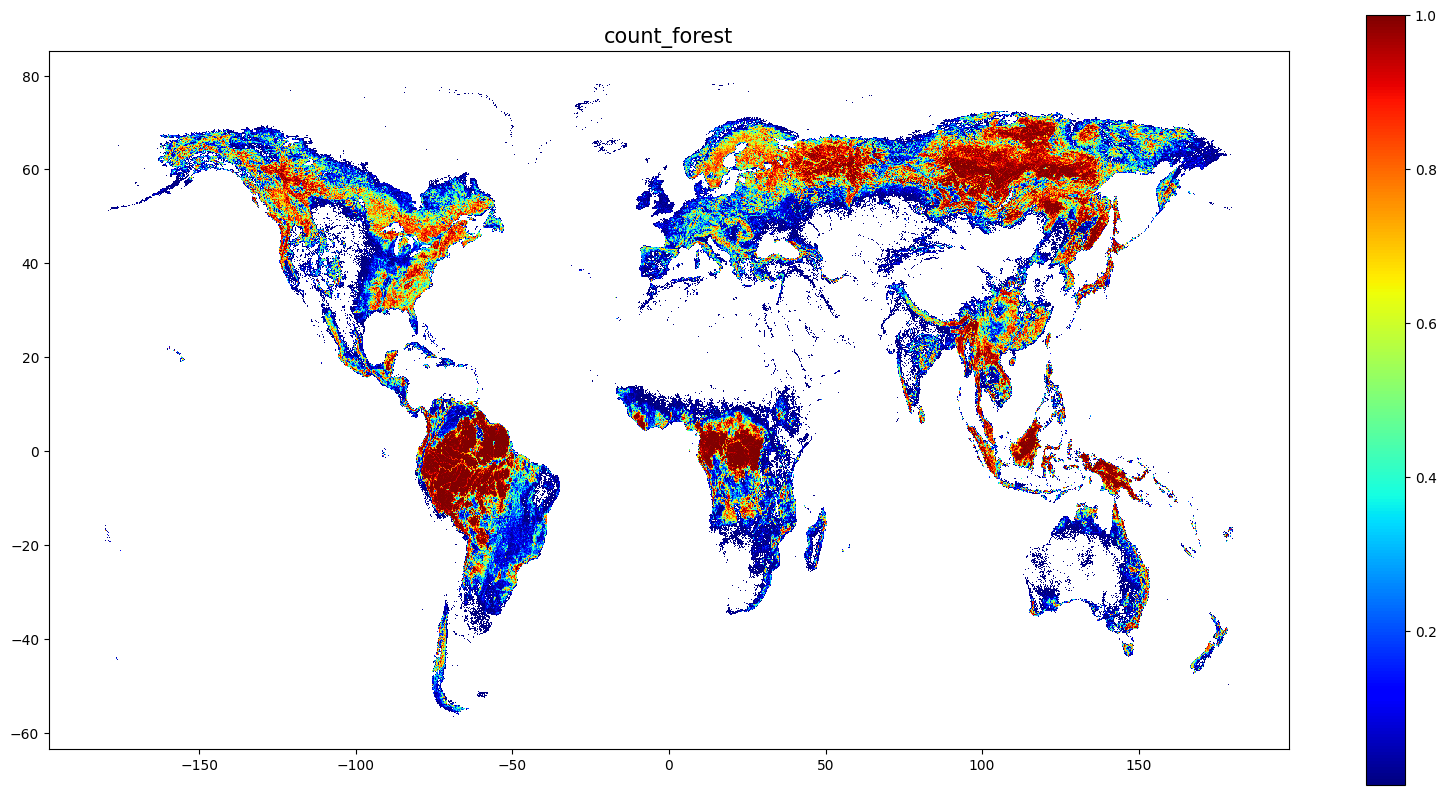

In [43]:
hist_col = 'count_forest' # Forest
gdf_plot = gdf_hist[gdf_hist[hist_col]>0]

ax = gdf_plot.plot(
    gdf_plot[hist_col]/gdf_plot['count'],
    cmap='jet',
    figsize=(20,10),
    legend=True,
)
ax.set_aspect(1.5)
# plt.xlim(-80, -40)
# plt.ylim(-50, -10)
plt.title(hist_col, size=15)
plt.show()

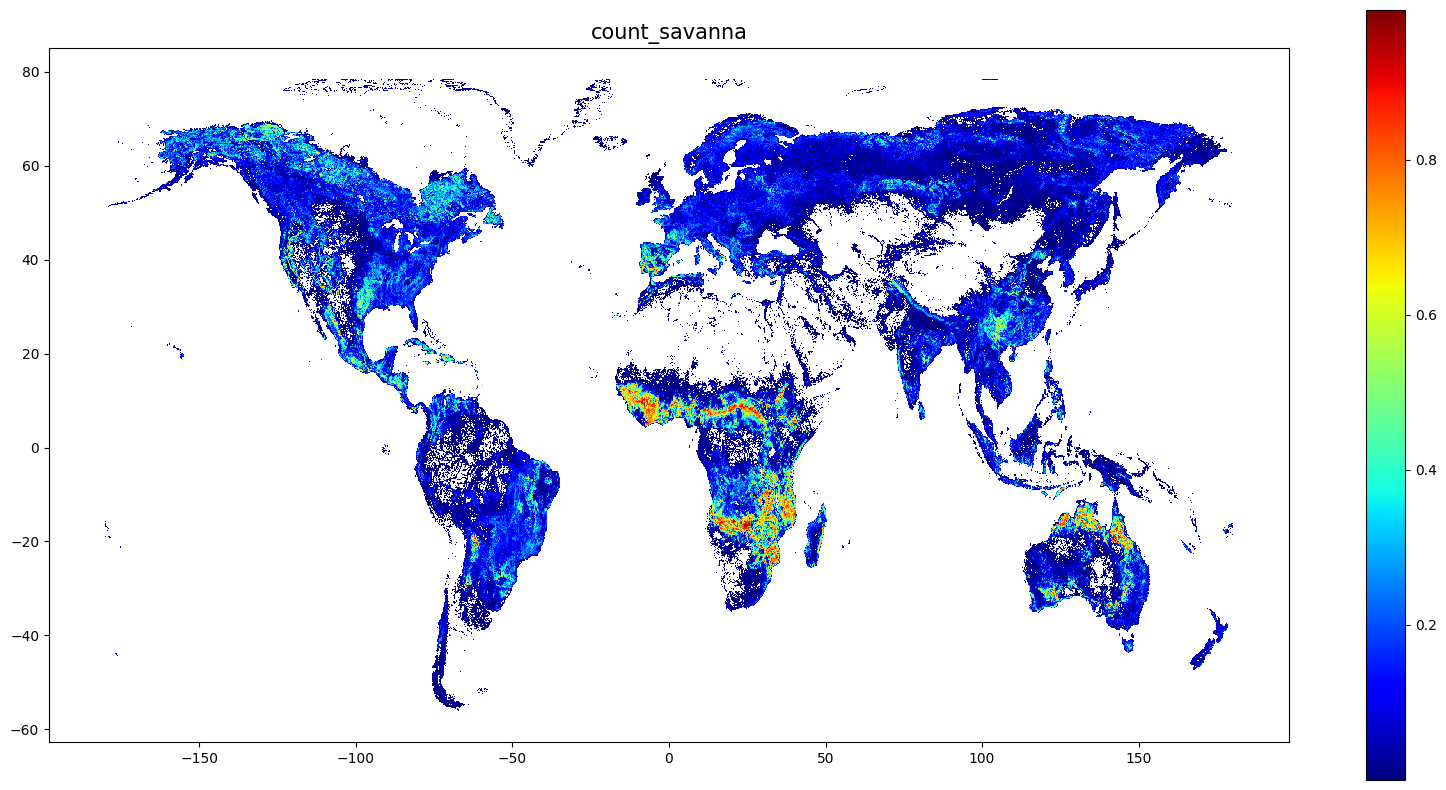

In [44]:
hist_col = 'count_savanna' # Savanna
gdf_plot = gdf_hist[gdf_hist[hist_col]>0]

ax = gdf_plot.plot(
    gdf_plot[hist_col]/gdf_plot['count'],
    cmap='jet',
    figsize=(20,10),
    legend=True,
)
ax.set_aspect(1.5)
# plt.xlim(-80, -40)
# plt.ylim(-50, -10)
plt.title(hist_col, size=15)
plt.show()

## Smart Sampling using the value-count (histogram) columns

In [45]:
rename_counts = {
    "count_50": "count_urban", 
}
gdf_count_urban = gdf_hist[['count' ,'count_50', 'top', 'geometry']].rename(columns=rename_counts)
gdf_count_urban = gdf_count_urban[gdf_count_urban['count_urban'].notnull()].reset_index(drop=True)

# For plotting purposes later, we keep the top category as well
rename_map = {
    0: "unknown", # -> skip
    20: "shrubs",
    30: "herbaceous_vegetation",
    40: "managed_vegetation",
    50: "urban",
    60: "bare_vegetation",
    70: "ice",
    80: "permanent_water",
    90: "wetland",
    100: "moss",
    111: "closed_forest",
    112: "closed_forest",
    113: "closed_forest",
    114: "closed_forest",
    115: "closed_forest",
    116: "closed_forest",
    121: "open_forest",
    122: "open_forest",
    123: "open_forest",
    124: "open_forest",
    125: "open_forest",
    126: "open_forest",
    200: "seas",
}
gdf_count_urban['top_label'] = gdf_count_urban['top'].astype(int).replace(rename_map)
#del gdf_count_urban['top']
gdf_count_urban = gdf_count_urban[gdf_count_urban['top_label']!='unknown'].reset_index(drop=True)
gdf_count_urban.tail()

,count,count_urban,top,geometry,top_label
1182554,65536,0.0,200,"POLYGON ((179.79264 69.12141, 179.79264 69.252...",seas
1182555,65536,0.0,200,"POLYGON ((179.66157 69.25248, 179.66157 69.383...",seas
1182556,65536,0.0,200,"POLYGON ((179.79264 69.25248, 179.79264 69.383...",seas
1182557,38144,0.0,200,"POLYGON ((179.92371 69.12141, 179.92371 69.252...",seas
1182558,38144,0.0,200,"POLYGON ((179.92371 69.25248, 179.92371 69.383...",seas


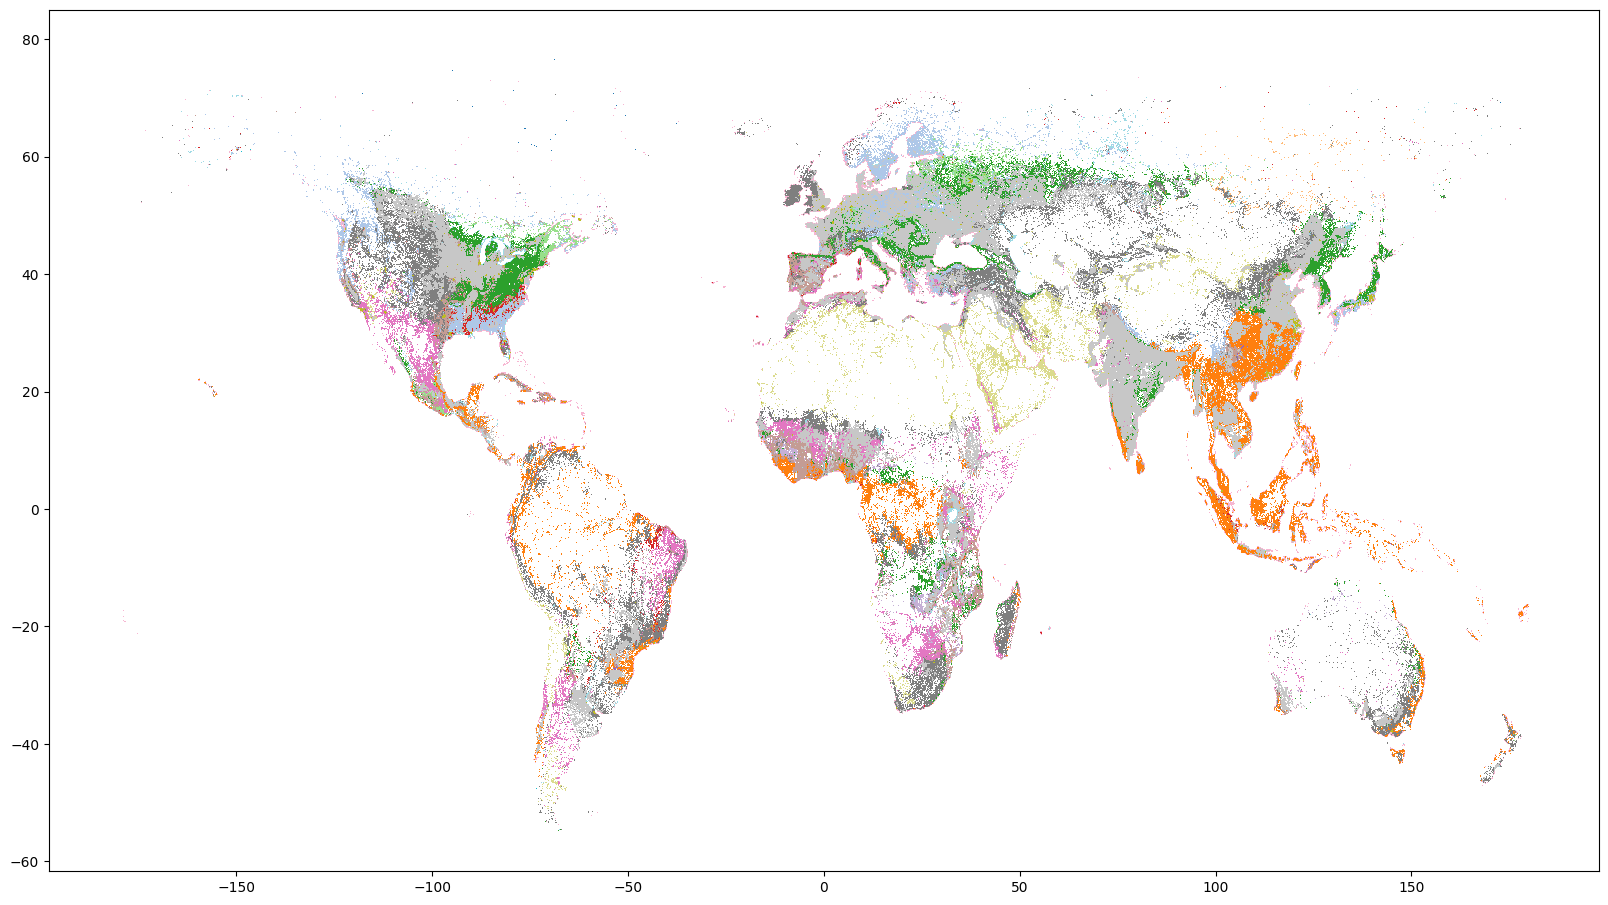

,count,count_urban,top,geometry,top_label
313139,65536,8.0,90,"POLYGON ((173.63226 65.18925, 173.63226 65.320...",wetland
313140,65536,124.0,100,"POLYGON ((172.71475 69.12141, 172.71475 69.252...",moss
313141,65536,8.0,30,"POLYGON ((173.63226 68.72819, 173.63226 68.859...",herbaceous_vegetation
313142,65536,20.0,30,"POLYGON ((173.63226 68.85926, 173.63226 68.990...",herbaceous_vegetation
313143,65536,68.0,30,"POLYGON ((177.43334 66.36890, 177.43334 66.499...",herbaceous_vegetation


In [46]:
# If we weight by urban acreage below we may as well drop count_urban zero rows
gdf_count_urban = gdf_count_urban[gdf_count_urban['count_urban']>0].reset_index(drop=True)
ax = gdf_count_urban.plot(gdf_count_urban['top'], cmap='tab20', figsize=(20,20))
ax.set_aspect(1.5)
plt.show()
gdf_count_urban.tail()

In [47]:
# Get the center Longitude and Latitude for every pixel
gdf_count_urban['Centroid'] = gdf_count_urban['geometry'].centroid
gdf_count_urban['Longitude'] = gdf_count_urban['geometry'].centroid.x
gdf_count_urban['Latitude'] = gdf_count_urban['geometry'].centroid.y

# Calculate area weights
gdf_count_urban['area_weights'] = gdf_count_urban['Latitude'].apply(
    lambda x: numpy.cos(numpy.deg2rad(x))
)

# Calculate urban weights
gdf_count_urban['urban_weights'] = gdf_count_urban['count_urban'] / gdf_count_urban['count']

gdf_count_urban.tail(2)

,count,count_urban,top,geometry,top_label,Centroid,Longitude,Latitude,area_weights,urban_weights
313142,65536,20.0,30,"POLYGON ((173.63226 68.85926, 173.63226 68.990...",herbaceous_vegetation,POINT (173.69779 68.92480),173.697792,68.924800,0.359593,0.000305
313143,65536,68.0,30,"POLYGON ((177.43334 66.36890, 177.43334 66.499...",herbaceous_vegetation,POINT (177.49888 66.43443),177.498880,66.434432,0.399798,0.001038


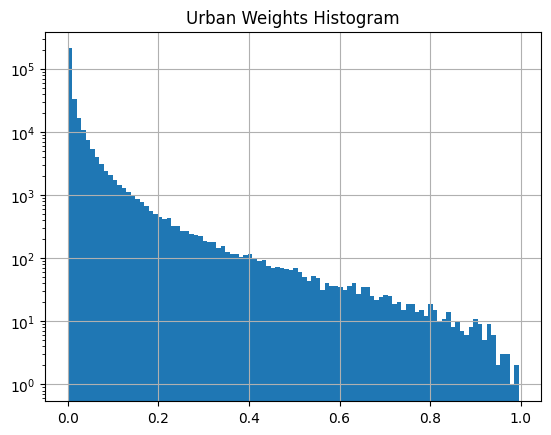

In [48]:
gdf_count_urban['urban_weights'].hist(bins=100, log=True)
plt.title('Urban Weights Histogram')
plt.show()

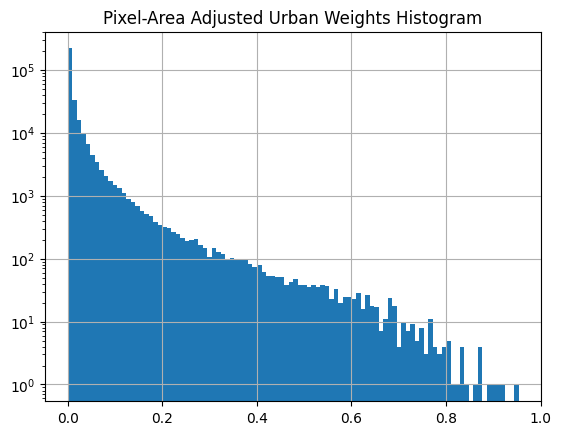

In [49]:
gdf_count_urban['urban_area_weights'] = gdf_count_urban['area_weights'] * gdf_count_urban['urban_weights']
gdf_count_urban['urban_area_weights'].hist(bins=100, log=True)
plt.title('Pixel-Area Adjusted Urban Weights Histogram')
plt.show()

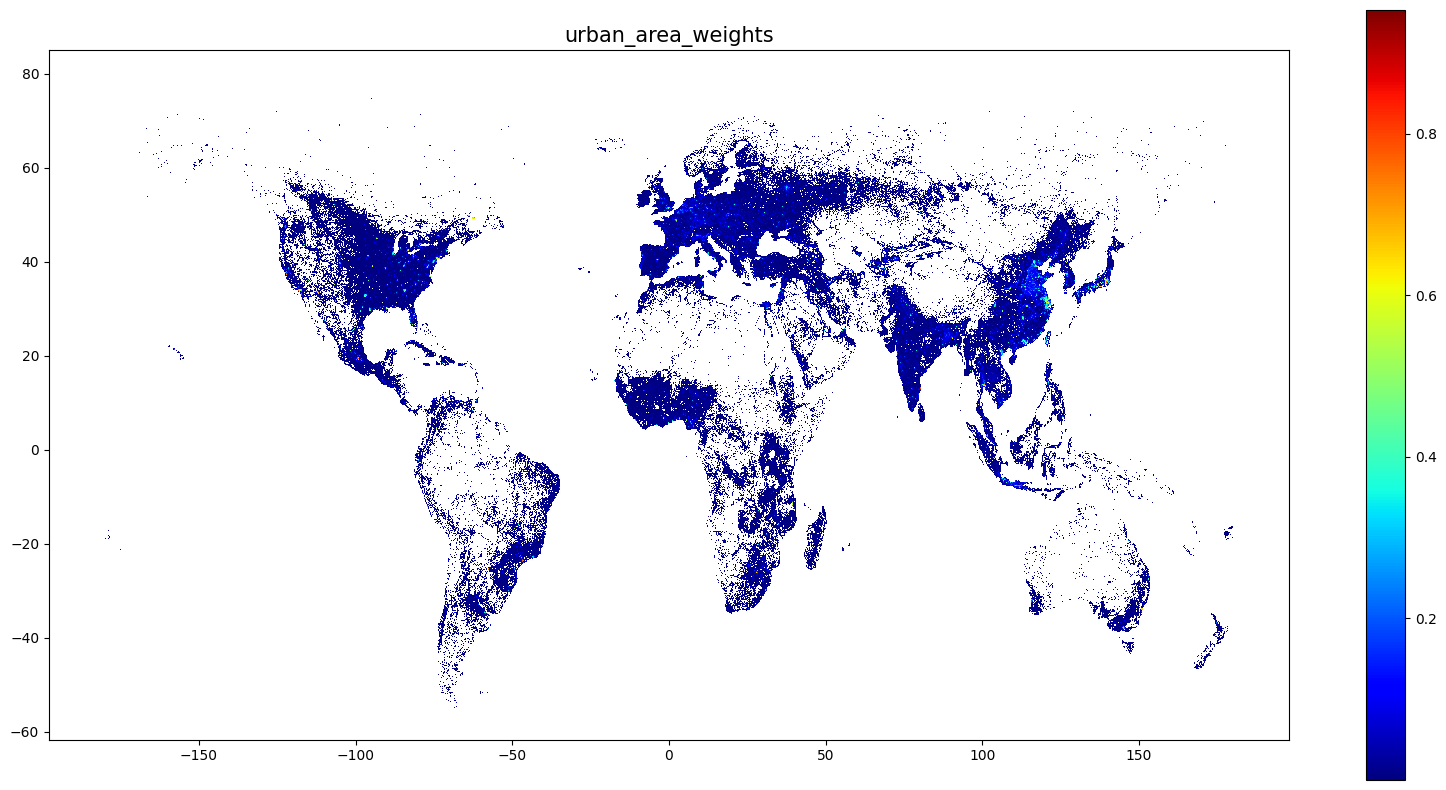

In [71]:
ax = gdf_count_urban.plot(
    gdf_count_urban['urban_area_weights'],
    cmap='jet',
    figsize=(20,10),
    legend=True,
)
ax.set_aspect(1.5)
# plt.xlim(-80, -40)
# plt.ylim(-50, -10)
plt.title('urban_area_weights', size=15)
plt.show()

In [50]:
total_number_of_items_to_pick = 1000
# p is a probability distribution
draw = numpy.random.choice(
    gdf_count_urban.index,
    size=total_number_of_items_to_pick, 
    replace=False,
    p=gdf_count_urban['urban_area_weights']/gdf_count_urban['urban_area_weights'].sum(),
)
df_draws = gdf_count_urban[gdf_count_urban.index.isin(draw)]
gdf_draws = geopandas.GeoDataFrame(df_draws, geometry='geometry').set_crs(4326)
gdf_draws.head(2)

,count,count_urban,top,geometry,top_label,Centroid,Longitude,Latitude,area_weights,urban_weights,urban_area_weights
1502,65536,4544.0,40,"POLYGON ((-71.60346 -35.86726, -71.60346 -35.7...",managed_vegetation,POINT (-71.53792 -35.80173),-71.537920,-35.801728,0.811046,0.069336,0.056235
2373,65536,40930.0,50,"POLYGON ((-70.81702 -33.50797, -70.81702 -33.3...",urban,POINT (-70.75149 -33.44243),-70.751488,-33.442432,0.834440,0.624542,0.521143


/tmp/ipykernel_993719/4211238341.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_plot['geometry'] = gdf_plot.buffer(1)


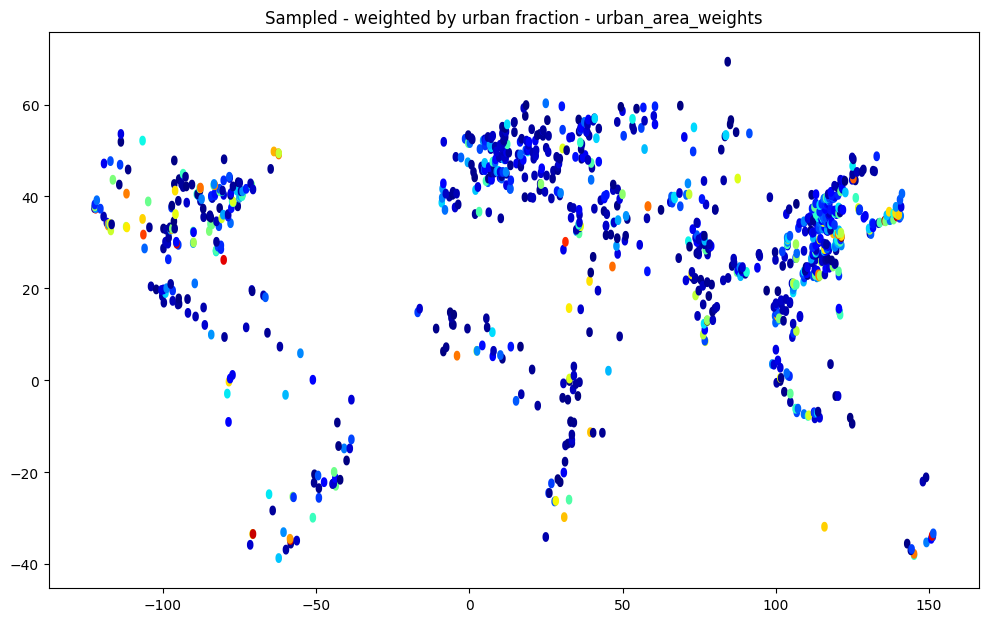

In [75]:
gdf_plot = gdf_draws.copy()
gdf_plot['geometry'] = gdf_plot.buffer(1)
fig, ax = plt.subplots(figsize=(12,12))
gdf_plot.plot(column="urban_area_weights", cmap='jet', ax=ax)
ax.set_aspect(1.5)
plt.title('Sampled - weighted by urban fraction - urban_area_weights')
plt.show()

/tmp/ipykernel_993719/134440972.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_plot['geometry'] = gdf_plot.buffer(1)


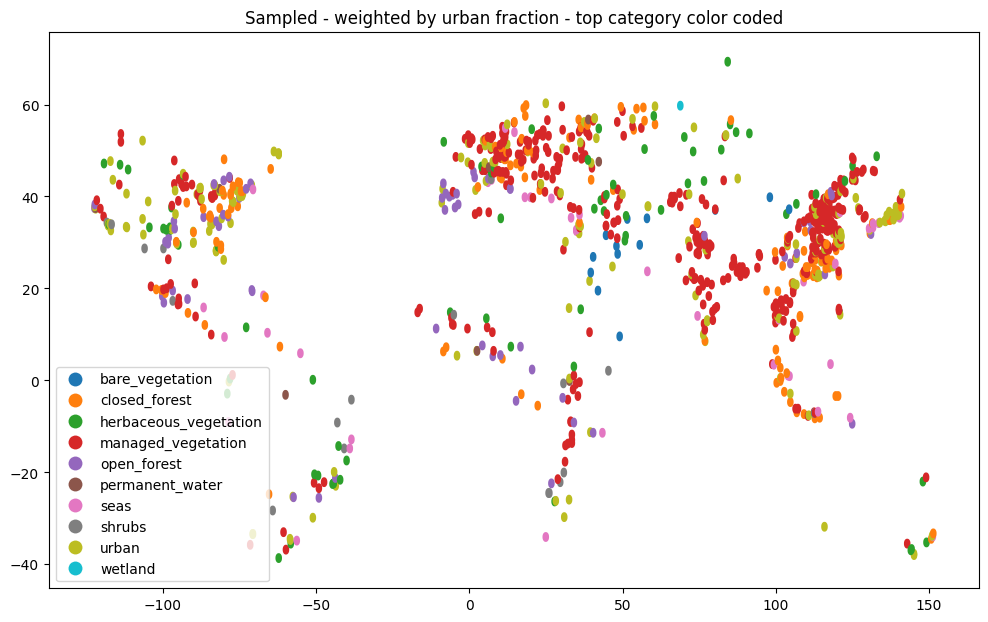

In [51]:
gdf_plot = gdf_draws.copy()
gdf_plot['geometry'] = gdf_plot.buffer(1)
fig, ax = plt.subplots(figsize=(12,12))
gdf_plot.plot(column="top_label", legend=True, legend_kwds={'loc': 'lower left'}, ax=ax)
ax.set_aspect(1.5)
plt.title('Sampled - weighted by urban fraction - top category color coded')
plt.show()

# Using mortoncurve and qtree classes

In [52]:
#https://github.ibm.com/GeoDN-Discovery/overviews
sys.path.insert(0, '../overviews')

In [53]:
import nestedgrid
import mortoncurve
import qtree
import partition
import rasteroverview

grid = nestedgrid.PAIRS()
morton = mortoncurve.Morton(grid)

In [54]:
raster = rasteroverview.Rasteroverview(
    dset_id=dset_id, 
    layer_id=layer_id, 
    pixel_level=pixel_level, 
    delta_pixel_overview=delta_pixel_overview,
)
#raster.from_json()

## Accessing a single spatial overview partition

In [55]:
spatial_partition_level = 7
print('spatial_partition_level', spatial_partition_level)

spatial_partition_level 7


In [56]:
%%time
# Choose a location
latitude = 36
longitude = -110
key = morton.get_key(latitude, longitude, spatial_partition_level)
spatial_partition = morton.encode(key, spatial_partition_level)[0]
print('spatial_partition', spatial_partition)

# Filter particular timestamp
dt1 = datetime(2019, 1, 1)

remote_fp = os.path.join(partition_dir, 'spatial_partition=' + spatial_partition).replace("\\","/")
storage_url = f's3://{remote_fp}'
print('storage_url        ', storage_url)

ddf = dask_geopandas.read_parquet(
    storage_url,
    storage_options={
        'key' : service_credentials['cos_hmac_keys']['access_key_id'],
        'secret' : service_credentials['cos_hmac_keys']['secret_access_key'],
        'client_kwargs' : {'endpoint_url': endpoint_url}
    },
    filters = [
        ('timestamp', '=', dt1),
    ],   
)
gdf = ddf.compute().reset_index(drop=True)
gdf.tail(2)

spatial_partition 0q0032220
storage_url         s3://geofm-sampling-strategies/stats_51353/dset_id=553/layer_id=51353/overview_level=12/spatial_partition=0q0032220
CPU times: user 152 ms, sys: 30 ms, total: 182 ms
Wall time: 956 ms


,q_key,geometry,timestamp,count,unique,top,freq,first,count_126,count_20,...,count_90,count_114,count_124,count_100,count_115,count_125,dset_id,layer_id,overview_level,spatial_partition
1022,0q003222033332,"POLYGON ((-108.95898 39.89235, -108.95898 40.0...",2019-01-01,65536,5,20,31401,126,11109,31401,...,0,0,0,0,0,0,553,51353,12,0q0032220
1023,0q003222033333,"POLYGON ((-108.82790 39.89235, -108.82790 40.0...",2019-01-01,65536,6,20,26050,126,21452,26050,...,0,0,0,0,0,0,553,51353,12,0q0032220


<AxesSubplot: >

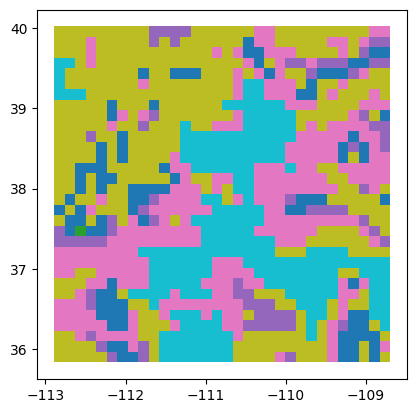

In [57]:
gdf.plot(gdf['top'])

<AxesSubplot: >

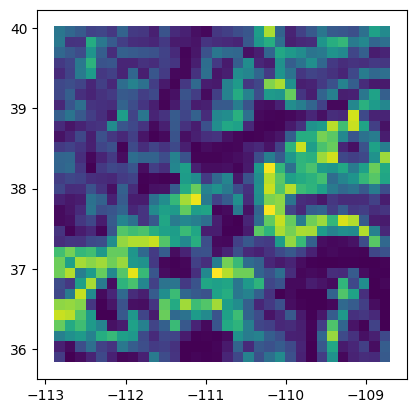

In [58]:
gdf.plot(gdf['count_20'])

## Querying the overviews in an entire area

In [59]:
my_poly = shapely.box(-110, 15, -90, 35)
qt = qtree.QTree(my_poly, spatial_partition_level)
keys = qt.gridded()
# Making it a list of base4 strings so we can use it below to filter
q_keys = [morton.encode(k, spatial_partition_level)[0] for k in keys]
len(q_keys)

30

In [60]:
storage_url = f's3://{s3_dir}'
print('storage_url  ', storage_url)

storage_url   s3://geofm-sampling-strategies/stats_51353


In [61]:
%%time
ddf = dask_geopandas.read_parquet(
    storage_url,
    storage_options={
        'key' : service_credentials['cos_hmac_keys']['access_key_id'],
        'secret' : service_credentials['cos_hmac_keys']['secret_access_key'],
        'client_kwargs' : {'endpoint_url': endpoint_url}
    },
    filters = [
        ('timestamp', '=', dt1),
        ('spatial_partition', 'in', q_keys),
    ],   
)

gdf = ddf.compute().reset_index(drop=True)
gdf.tail(2)

CPU times: user 15.3 s, sys: 1.41 s, total: 16.7 s
Wall time: 16.2 s


,q_key,geometry,timestamp,count,unique,top,freq,first,count_200,dset_id,layer_id,overview_level,spatial_partition
30718,0q003230333332,"POLYGON ((-87.98746 35.69805, -87.98746 35.829...",2019-01-01,65536,11,114,52831,114,NaN,553,51353,12,0q0032303
30719,0q003230333333,"POLYGON ((-87.85638 35.69805, -87.85638 35.829...",2019-01-01,65536,9,114,51789,114,NaN,553,51353,12,0q0032303


<AxesSubplot: >

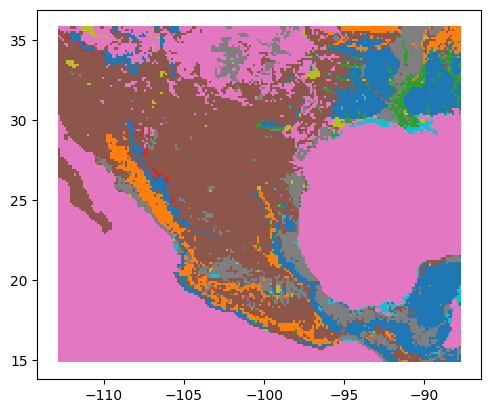

In [62]:
gdf.plot(gdf['top'])

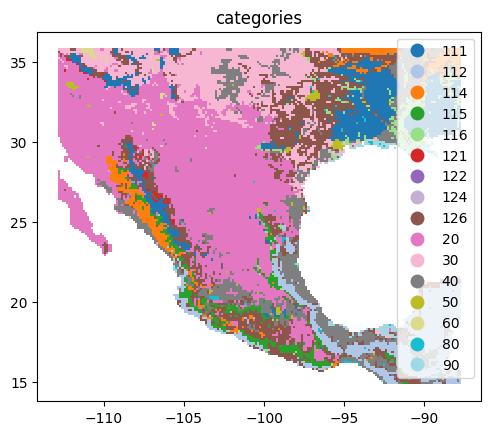

In [63]:
gdf_plot = gdf[gdf['top']!='200'] # remove open saltwater seas
gdf_plot.plot(
    gdf_plot['top'],
    cmap='tab20',
    legend=True
)
plt.title('categories')
plt.show()

## Special case histogram columns

Because histogram column names may be different for every parquet file, we need to query them separately if we are interested in those

In [64]:
hist_col = 'count_40' # Agriculture 

In [65]:
%%time
gdf = []
for spatial_partition in q_keys:
    remote_fp = os.path.join(partition_dir, 'spatial_partition=' + spatial_partition).replace("\\","/")
    storage_url = f's3://{remote_fp}'
    #print('storage_url        ', storage_url)
    try:
        ddf1 = dask_geopandas.read_parquet(
            storage_url,
            storage_options={
                'key' : service_credentials['cos_hmac_keys']['access_key_id'],
                'secret' : service_credentials['cos_hmac_keys']['secret_access_key'],
                'client_kwargs' : {'endpoint_url': endpoint_url}
            },
            filters = [
                ('timestamp', '=', dt1),
                #('spatial_partition', '=', spatial_partition),
            ],   
            #columns=['q_key', 'geometry', 'timestamp', 'count', hist_col]
        )

    except:
        pass
    else:
        gdf.append(ddf1.compute())
gdf = pandas.concat(gdf).reset_index(drop=True)
gdf.tail(2)

CPU times: user 3.65 s, sys: 403 ms, total: 4.05 s
Wall time: 8.64 s


,q_key,geometry,timestamp,count,unique,top,freq,first,count_200,count_80,...,spatial_partition,count_112,count_114,count_115,count_122,count_50,count_125,count_124,count_0,count_70
30718,0q003230333332,"POLYGON ((-87.98746 35.69805, -87.98746 35.829...",2019-01-01,65536,11,114,52831,114,NaN,1624.0,...,0q0032303,NaN,52831.0,0.0,NaN,81.0,NaN,280.0,0.0,NaN
30719,0q003230333333,"POLYGON ((-87.85638 35.69805, -87.85638 35.829...",2019-01-01,65536,9,114,51789,114,NaN,0.0,...,0q0032303,NaN,51789.0,0.0,NaN,234.0,NaN,334.0,0.0,NaN


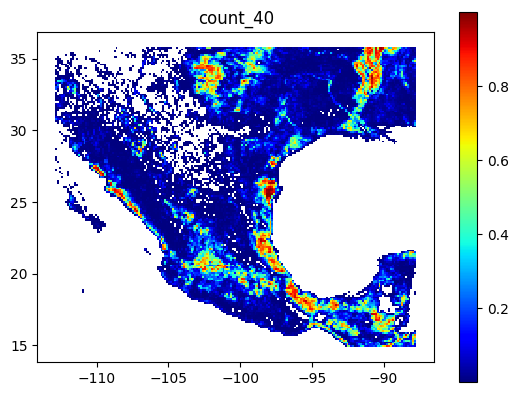

In [66]:
gdf_plot = gdf[gdf[hist_col]>0]
ax = gdf_plot.plot(
    gdf_plot[hist_col]/gdf_plot['count'],
    cmap='jet',
    legend=True,
)
ax.set_aspect(1)
plt.title(hist_col)
plt.show()

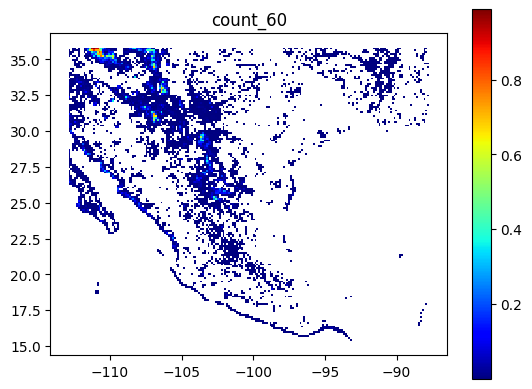

In [67]:
hist_col = 'count_60' # Bare Soil / Sparse vegetation
gdf_plot = gdf[gdf[hist_col]>0]
ax = gdf_plot.plot(
    gdf_plot[hist_col]/gdf_plot['count'],
    cmap='jet',
    legend=True,
)
ax.set_aspect(1)
plt.title(hist_col)
plt.show()

## Copernicus classes

In [68]:
# Copernicus classes
# 0	#282828	Unknown. No or not enough satellite data available.
# 20	#ffbb22	Shrubs. Woody perennial plants with persistent and woody stems and without any defined main stem being less than 5 m tall. The shrub foliage can be either evergreen or deciduous.
# 30	#ffff4c	Herbaceous vegetation. Plants without persistent stem or shoots above ground and lacking definite firm structure. Tree and shrub cover is less than 10 %.
# 40	#f096ff	Cultivated and managed vegetation / agriculture. Lands covered with temporary crops followed by harvest and a bare soil period (e.g., single and multiple cropping systems). Note that perennial woody crops will be classified as the appropriate forest or shrub land cover type.
# 50	#fa0000	Urban / built up. Land covered by buildings and other man-made structures.
# 60	#b4b4b4	Bare / sparse vegetation. Lands with exposed soil, sand, or rocks and never has more than 10 % vegetated cover during any time of the year.
# 70	#f0f0f0	Snow and ice. Lands under snow or ice cover throughout the year.
# 80	#0032c8	Permanent water bodies. Lakes, reservoirs, and rivers. Can be either fresh or salt-water bodies.
# 90	#0096a0	Herbaceous wetland. Lands with a permanent mixture of water and herbaceous or woody vegetation. The vegetation can be present in either salt, brackish, or fresh water.
# 100	#fae6a0	Moss and lichen.
# 111	#58481f	Closed forest, evergreen needle leaf. Tree canopy >70 %, almost all needle leaf trees remain green all year. Canopy is never without green foliage.
# 112	#009900	Closed forest, evergreen broad leaf. Tree canopy >70 %, almost all broadleaf trees remain green year round. Canopy is never without green foliage.
# 113	#70663e	Closed forest, deciduous needle leaf. Tree canopy >70 %, consists of seasonal needle leaf tree communities with an annual cycle of leaf-on and leaf-off periods.
# 114	#00cc00	Closed forest, deciduous broad leaf. Tree canopy >70 %, consists of seasonal broadleaf tree communities with an annual cycle of leaf-on and leaf-off periods.
# 115	#4e751f	Closed forest, mixed.
# 116	#007800	Closed forest, not matching any of the other definitions.
# 121	#666000	Open forest, evergreen needle leaf. Top layer- trees 15-70 % and second layer- mixed of shrubs and grassland, almost all needle leaf trees remain green all year. Canopy is never without green foliage.
# 122	#8db400	Open forest, evergreen broad leaf. Top layer- trees 15-70 % and second layer- mixed of shrubs and grassland, almost all broadleaf trees remain green year round. Canopy is never without green foliage.
# 123	#8d7400	Open forest, deciduous needle leaf. Top layer- trees 15-70 % and second layer- mixed of shrubs and grassland, consists of seasonal needle leaf tree communities with an annual cycle of leaf-on and leaf-off periods.
# 124	#a0dc00	Open forest, deciduous broad leaf. Top layer- trees 15-70 % and second layer- mixed of shrubs and grassland, consists of seasonal broadleaf tree communities with an annual cycle of leaf-on and leaf-off periods.
# 125	#929900	Open forest, mixed.
# 126	#648c00	Open forest, not matching any of the other definitions.
# 200	#000080	Oceans, seas. Can be either fresh or salt-water bodies.